## Проект: "Определение стоимости автомобиля"

### Цель проекта:

- Провести небольшой аналитический отчет, о влиянии признаков на конечную стоимость автомобиля.
- Подготовить модель машинного обучения, для определения рыночной стоимости автомобиля.

### План проекта:

1. Загрузка данных и первичный осмотр.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Создание модели машинного обучения.
5. Итоговый вывод.

### Описание данных:

•	**DateCrawled** — дата скачивания анкеты из базы  
•	**VehicleType** — тип автомобильного кузова  
•	**RegistrationYear** — год регистрации автомобиля  
•	**Gearbox** — тип коробки передач  
•	**Power** — мощность (л. с.)  
•	**Model** — модель автомобиля  
•	**Kilometer** — пробег (км)  
•	**RegistrationMonth** — месяц регистрации автомобиля  
•	**FuelType** — тип топлива  
•	**Brand** — марка автомобиля  
•	**Repaired** — была машина в ремонте или нет  
•	**DateCreated** — дата создания анкеты  
•	**NumberOfPictures** — количество фотографий автомобиля  
•	**PostalCode** — почтовый индекс владельца анкеты (пользователя)  
•	**LastSeen** — дата последней активности пользователя


#### Дополнение к описанию данных:

Для интерпретации данных, будем иметь в виду следующее:
- **RegistrationYear** — год регистрации автомобиля -- Регистрации первичная и совпадает с датой выпуска автомобиля.  
- **PostalCode** — почтовый индекс владельца анкеты (пользователя) -- Иными словами - регион использования автомобиля.

## 1. Загрузка данных

Загрузим необходимые библиотеки и сделаем импорты.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error

from lightgbm import LGBMRegressor 
from catboost import CatBoostRegressor

In [2]:
!pip install phik -q


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import phik

Загружаем и смотрим датасет.

In [4]:
car = pd.read_csv('autos.csv')

In [5]:
display(car.head())
print(f'Размер датасета: {car.shape}')

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


Размер датасета: (354369, 16)


Имеем датасет на 354тыс. строк и 16 столбцов. Далее переходим к предобработке данных.

## 2. Предобработка данных

Посмотрим пропуски, дубликаты и типы данных.

In [6]:
print(car.isna().sum().sort_values(ascending = False))
print('--' * 30)
print(car.duplicated().sum())
print('--' * 30)
print(car.dtypes)

Repaired             71154
VehicleType          37490
FuelType             32895
Gearbox              19833
Model                19705
DateCrawled              0
Price                    0
RegistrationYear         0
Power                    0
Kilometer                0
RegistrationMonth        0
Brand                    0
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
dtype: int64
------------------------------------------------------------
4
------------------------------------------------------------
DateCrawled            str
Price                int64
VehicleType            str
RegistrationYear     int64
Gearbox                str
Power                int64
Model                  str
Kilometer            int64
RegistrationMonth    int64
FuelType               str
Brand                  str
Repaired               str
DateCreated            str
NumberOfPictures     int64
PostalCode           int64
LastSeen               str

Имеем большое количество пропусков в разных столбцах, что с ними делать решим позже.  
Так же есть 4 строки дубликата, их удалим.  
Типы данных в порядке, за исключением столбца с датой. Его поставим в верный тип.  
Удалим не нужные столбцы: DataCrawled, LastSeen.

In [7]:
car = car.drop_duplicates()

In [8]:
# проверка дубликатов

car.duplicated().sum()

np.int64(0)

In [9]:
# изменение типа данных

car['DateCreated'] = car['DateCreated'].astype('datetime64[ns]')

In [10]:
# проверка

car['DateCreated'].dtype

dtype('<M8[ns]')

In [11]:
car = car.drop(columns = ['DateCrawled', 'LastSeen'])

In [12]:
# проверка столбцов

car.columns

Index(['Price', 'VehicleType', 'RegistrationYear', 'Gearbox', 'Power', 'Model',
       'Kilometer', 'RegistrationMonth', 'FuelType', 'Brand', 'Repaired',
       'DateCreated', 'NumberOfPictures', 'PostalCode'],
      dtype='str')

In [13]:
car.head()

,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode
0,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24,0,70435
1,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24,0,66954
2,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14,0,90480
3,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17,0,91074
4,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31,0,60437


Посмотрим уникальные значения в столбцах.

In [14]:
for col in car.columns:
    print(f"\n{col}:")
    print("Уникальных:", car[col].nunique())
        
    if car[col].nunique() < 50:
        print("Значения:", sorted(car[col].dropna().unique()))


Price:
Уникальных: 3731

VehicleType:
Уникальных: 8
Значения: ['bus', 'convertible', 'coupe', 'other', 'sedan', 'small', 'suv', 'wagon']

RegistrationYear:
Уникальных: 151

Gearbox:
Уникальных: 2
Значения: ['auto', 'manual']

Power:
Уникальных: 712

Model:
Уникальных: 250

Kilometer:
Уникальных: 13
Значения: [np.int64(5000), np.int64(10000), np.int64(20000), np.int64(30000), np.int64(40000), np.int64(50000), np.int64(60000), np.int64(70000), np.int64(80000), np.int64(90000), np.int64(100000), np.int64(125000), np.int64(150000)]

RegistrationMonth:
Уникальных: 13
Значения: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

FuelType:
Уникальных: 7
Значения: ['cng', 'electric', 'gasoline', 'hybrid', 'lpg', 'other', 'petrol']

Brand:
Уникальных: 40
Значения: ['alfa_romeo', 'audi', 'bmw', 'chevrolet', 'chrysler', 'citroen', 'dacia', 'daewoo', 'daihatsu', 'fiat', 'ford'

Особых проблем не обнаруженно. Столбец с колличеством фото пустой, так же удалим. И заодно столбец с месяцем регистрации.

In [15]:
# удаляем столбец с фото

car = car.drop(columns = ['NumberOfPictures', 'RegistrationMonth'])

In [16]:
# проверка

car.columns

Index(['Price', 'VehicleType', 'RegistrationYear', 'Gearbox', 'Power', 'Model',
       'Kilometer', 'FuelType', 'Brand', 'Repaired', 'DateCreated',
       'PostalCode'],
      dtype='str')

С предобработкой закончили. Переходим к исследовательскому анализу данных.

## 3. Исследовательский анализ данных

Для начала сделаем статистический анализ.

In [17]:
display(car.describe(include = 'number'))
display(car.describe(exclude='number'))

,Price,RegistrationYear,Power,Kilometer,PostalCode
count,354365.000000,354365.000000,354365.000000,354365.000000,354365.000000
mean,4416.679830,2004.234481,110.093816,128211.363989,50508.503800
std,4514.176349,90.228466,189.851330,37905.083858,25783.100078
min,0.000000,1000.000000,0.000000,5000.000000,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,99998.000000


,VehicleType,Gearbox,Model,FuelType,Brand,Repaired,DateCreated
count,316875,334532,334660,321470,354365,283211,354365
unique,8,2,250,7,40,2,NaN
top,sedan,manual,golf,petrol,volkswagen,no,NaN
freq,91457,268249,29232,216349,77012,247158,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,2016-03-20 19:12:06.583042560
min,NaN,NaN,NaN,NaN,NaN,NaN,2014-03-10 00:00:00
25%,NaN,NaN,NaN,NaN,NaN,NaN,2016-03-13 00:00:00
50%,NaN,NaN,NaN,NaN,NaN,NaN,2016-03-21 00:00:00
75%,NaN,NaN,NaN,NaN,NaN,NaN,2016-03-29 00:00:00
max,NaN,NaN,NaN,NaN,NaN,NaN,2016-04-07 00:00:00


- ошибки по цене
- ошибки по году выпуска
- ошибки по мощности  
Сразу же уберем их.

In [18]:
# сразу же удалим автомобили с неверной ценой

car = car[car['Price'] > 1]

In [19]:
# посчитаем количество проблемных строк, для безопасного удаления по году

print(f"Проблемных: {len(car[(car['RegistrationYear'] <= 1950) | (car['RegistrationYear'] >= 2025)])}")
print(f'Всего: {len(car)}')

Проблемных: 259
Всего: 342404


In [20]:
# убираем проблемные строки

car = car[(car['RegistrationYear'] >= 1950) & (car['RegistrationYear'] <= 2025)]

In [21]:
print(f'Всего: {len(car)}')

Всего: 342160


In [22]:
# посчитаем количество проблемных строк, для безопасного удаления по мощности

print(f"Проблемных: {len(car[(car['Power'] <= 30) | (car['Power'] >= 1000)])}")

Проблемных: 36852


Количество проблемных строк с мощностью много, поэтому принимаем решение частично вручную отредактировать.

In [23]:
# для начала посмотрим количество с меньшей мощностью

print(f"Меньше 30 лс: {len(car[car['Power'] <= 30])}")
print(f"0 лс: {len(car[car['Power'] == 0])}")

Меньше 30 лс: 36571
0 лс: 35711


Особо вариантов не остается, удаляем строки с мощностью менее 30 лс.

In [24]:
car = car[car['Power'] >= 30]

In [25]:
# проверка

len(car)

305619

In [26]:
# посмотрим на количество свыше 500, 750, 1000 лс

print(f"Свыше 500 лс: {len(car[car['Power'] >= 500])}")
print(f"Свыше 750 лс: {len(car[car['Power'] >= 750])}")
print(f"Свыше 1000 лс: {len(car[car['Power'] >= 1000])}")

Свыше 500 лс: 449
Свыше 750 лс: 315
Свыше 1000 лс: 281


Делаем следующий вывод. Для массмаркета, мы можем настроить модель, без учета редких мощных авто.  
В крйнем случае, для оценки редкого автомобиля, можно использовать ручную оценку.  
Итог - удаляем из датасета авто с мощностью свыше 500 лс.

In [27]:
car = car[car['Power'] <= 500]

In [28]:
# проверка

len(car)

305204

In [29]:
# сделаем распределение по номинальным и категориальным столбцам

num_cols = car.select_dtypes(include = 'number').columns.to_list()
cat_cols = car.select_dtypes(exclude = 'number').columns.to_list()

print(f'Категориальные: {cat_cols}')
print(f'Номинальные: {num_cols}')

Категориальные: ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'Repaired', 'DateCreated']
Номинальные: ['Price', 'RegistrationYear', 'Power', 'Kilometer', 'PostalCode']


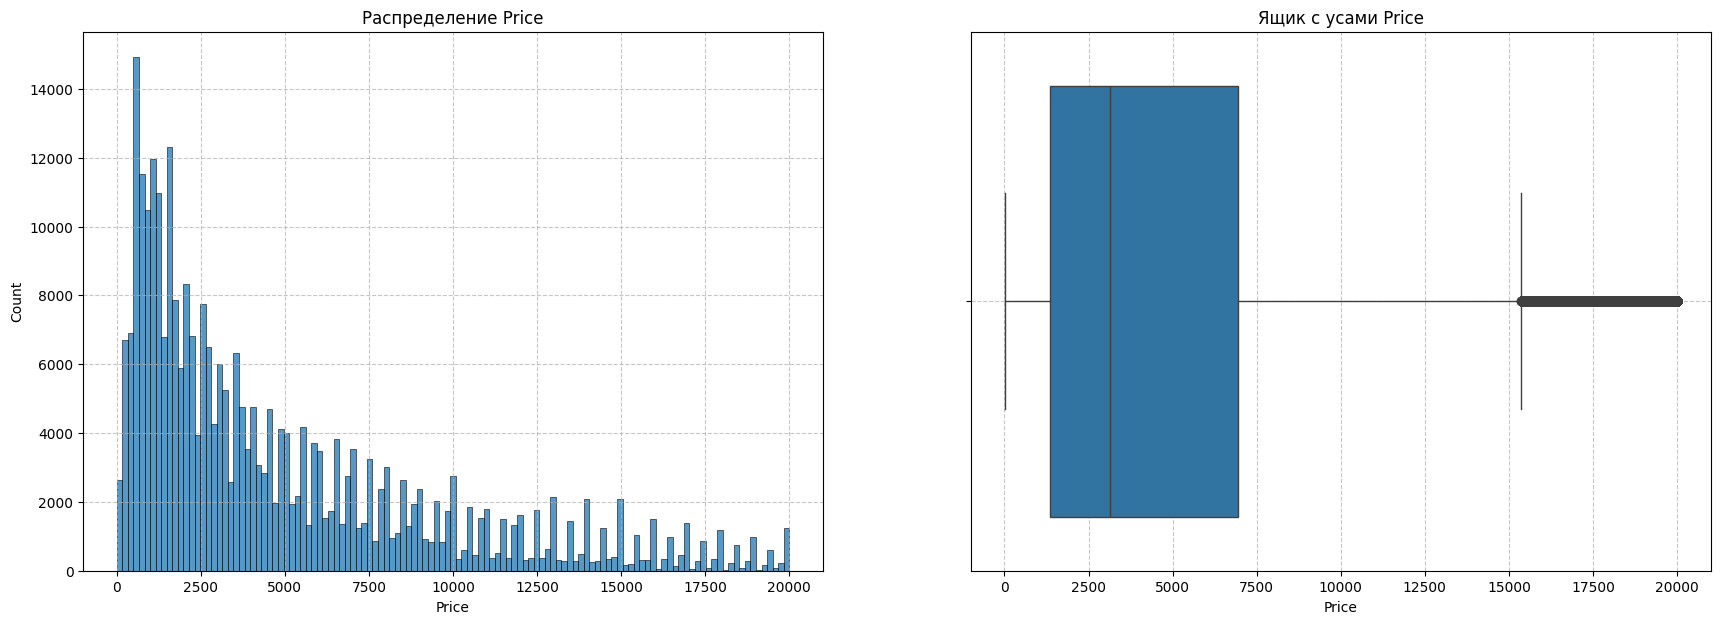

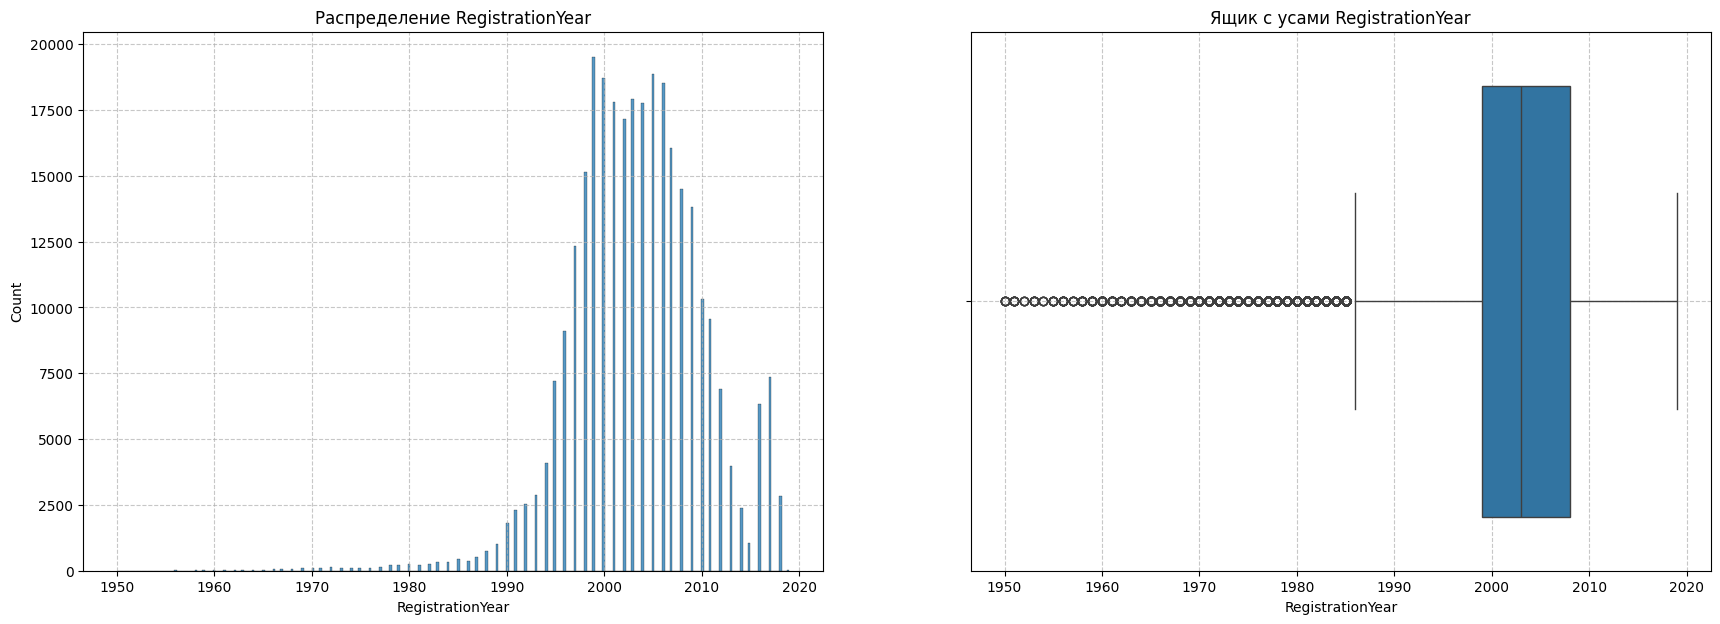

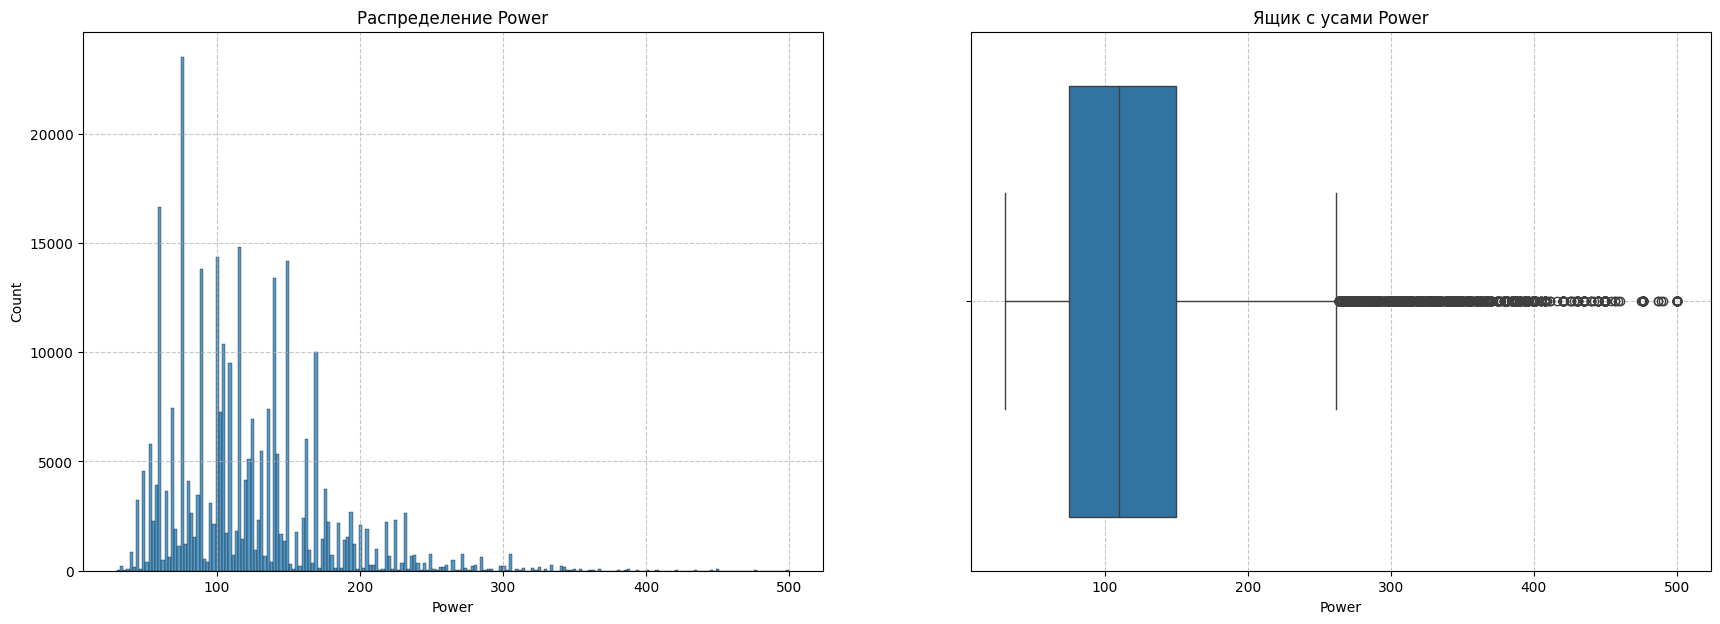

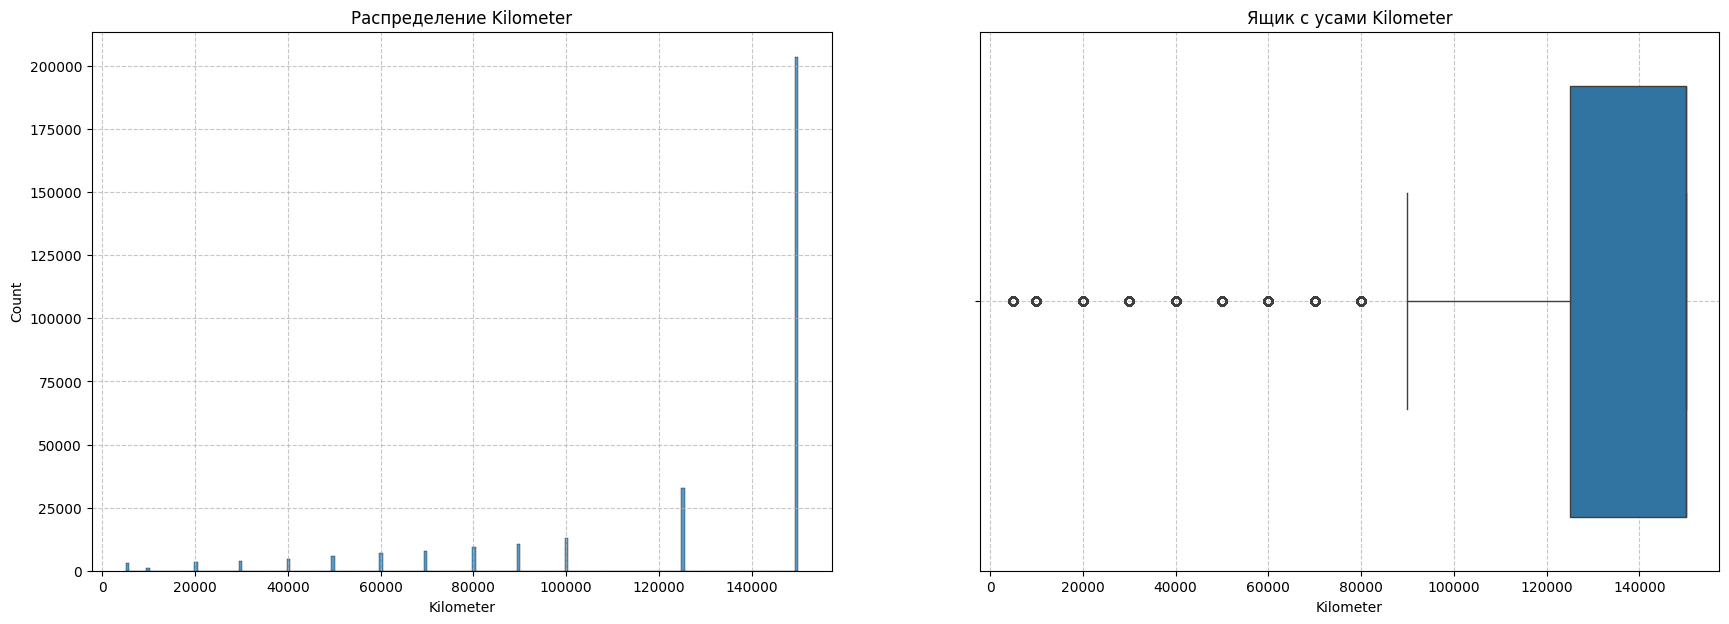

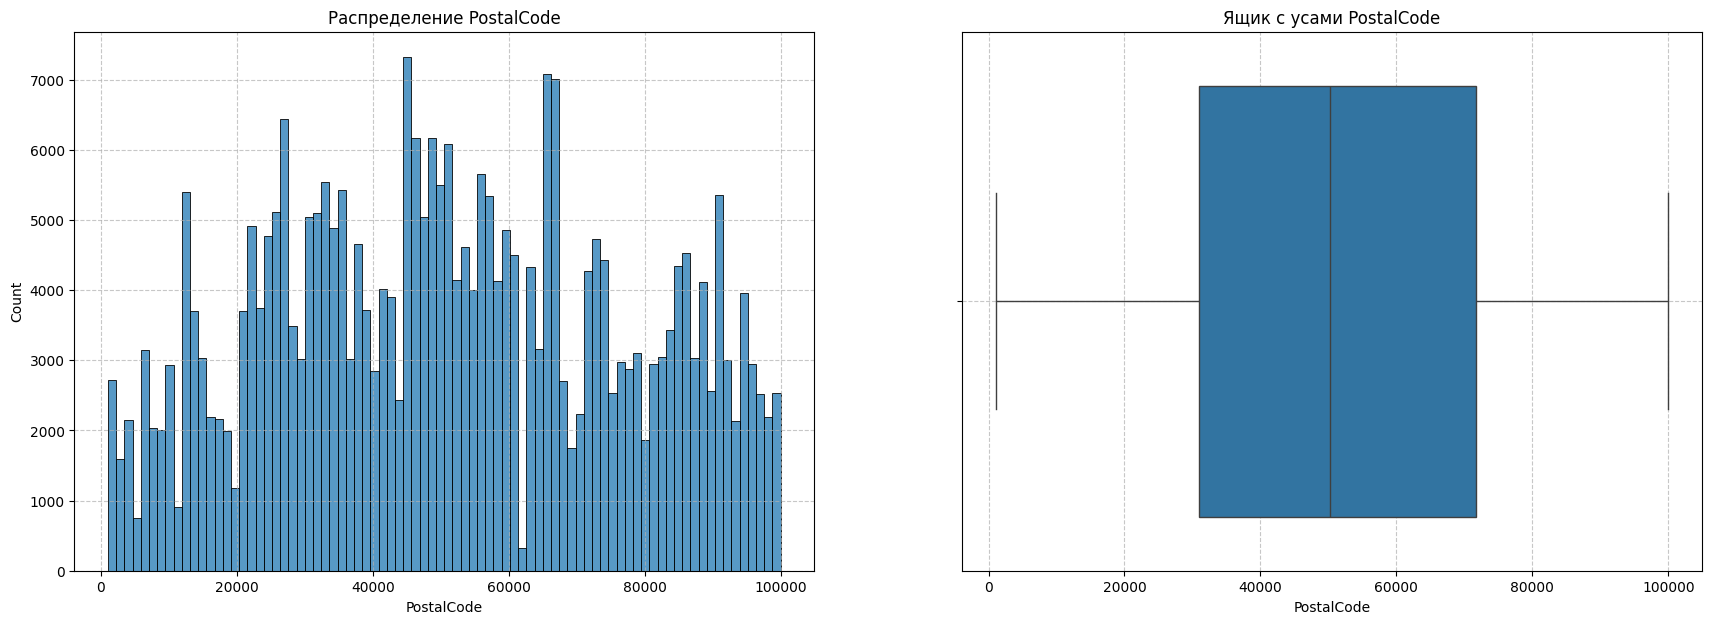

In [30]:
for a in num_cols:
    fig, ax = plt.subplots(1, 2, figsize = (21, 7))
    sns.histplot(
        data = car,
        x = a,
        bins = 'auto',
        ax = ax[0]
    )
    ax[0].grid(True, linestyle = '--', alpha = 0.7)
    ax[0].set_title(f'Распределение {a}')

    sns.boxplot(
        data = car,
        x = a,
        ax = ax[1]
    )
    ax[1].grid(True, linestyle = '--', alpha = 0.7)
    ax[1].set_title(f'Ящик с усами {a}')

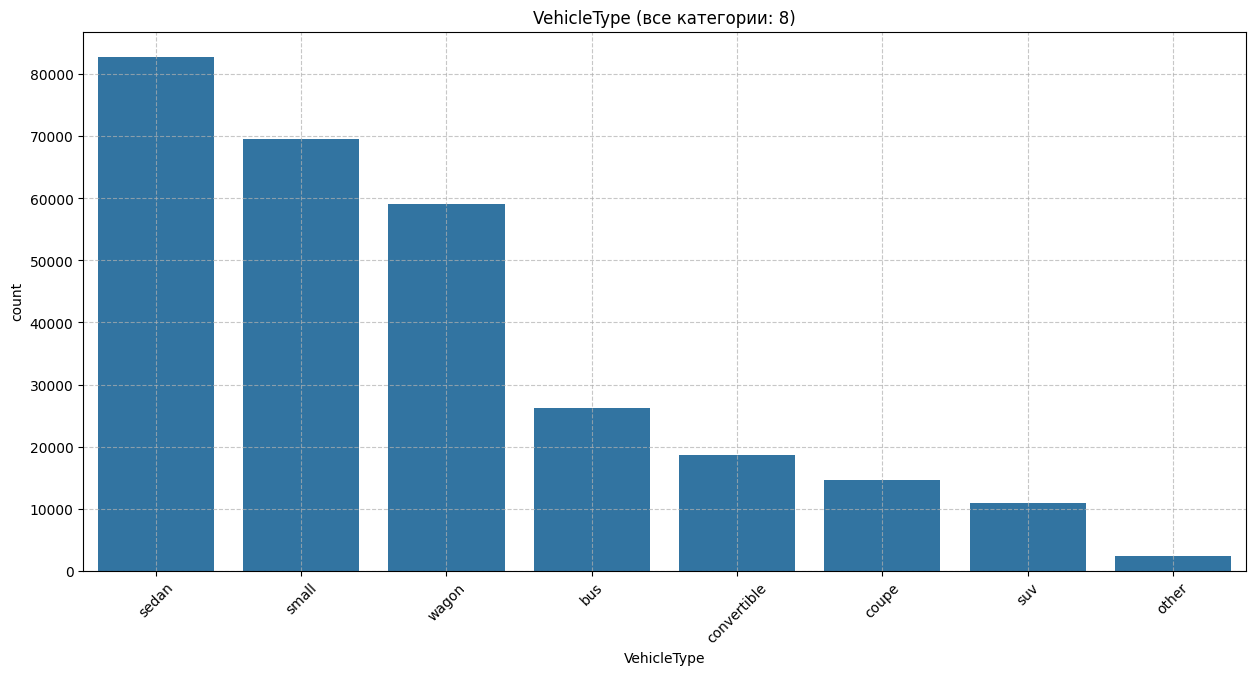

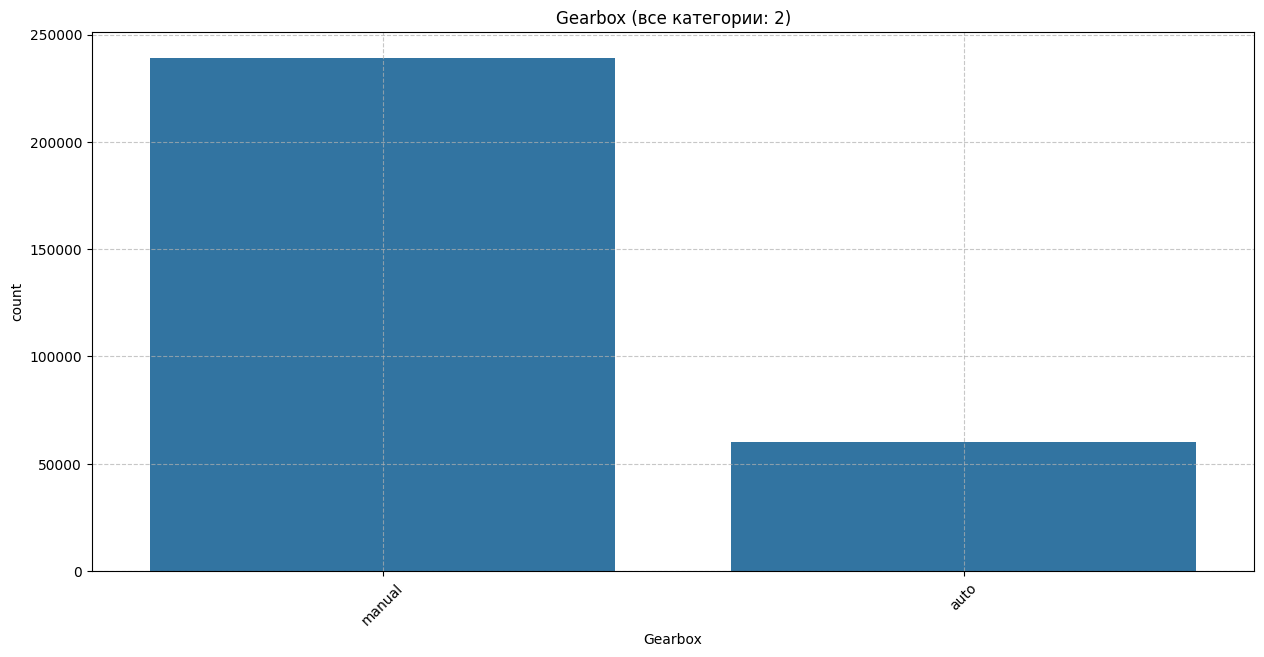

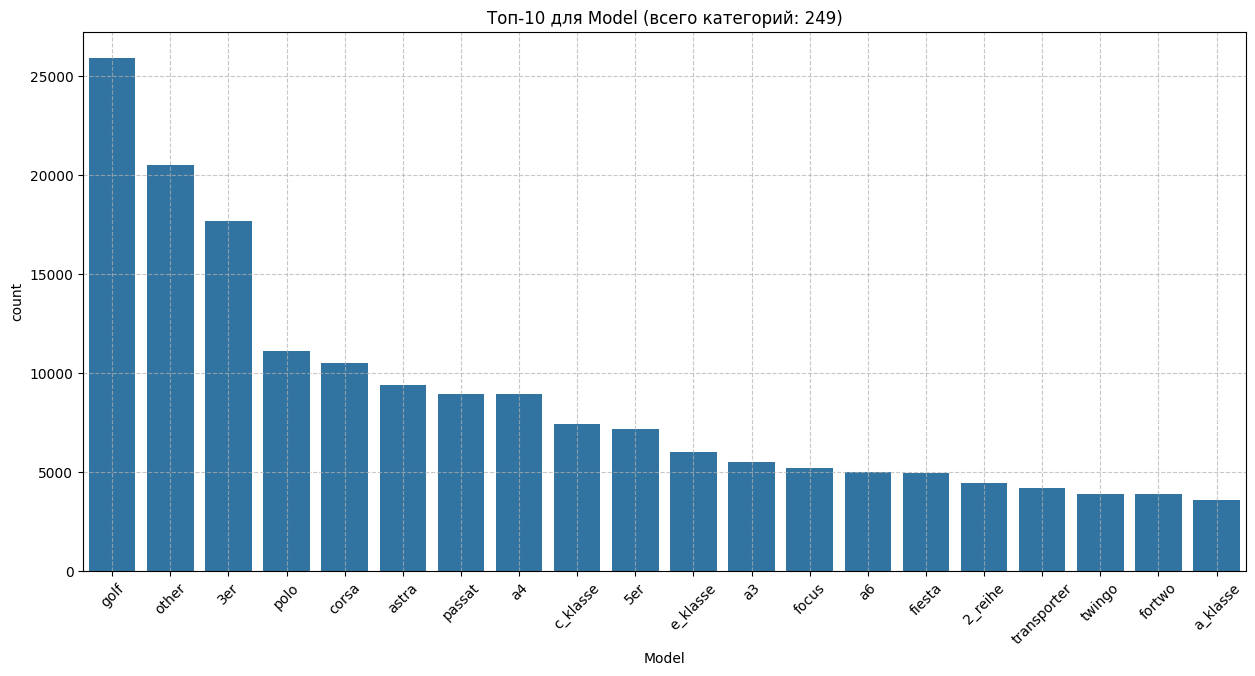

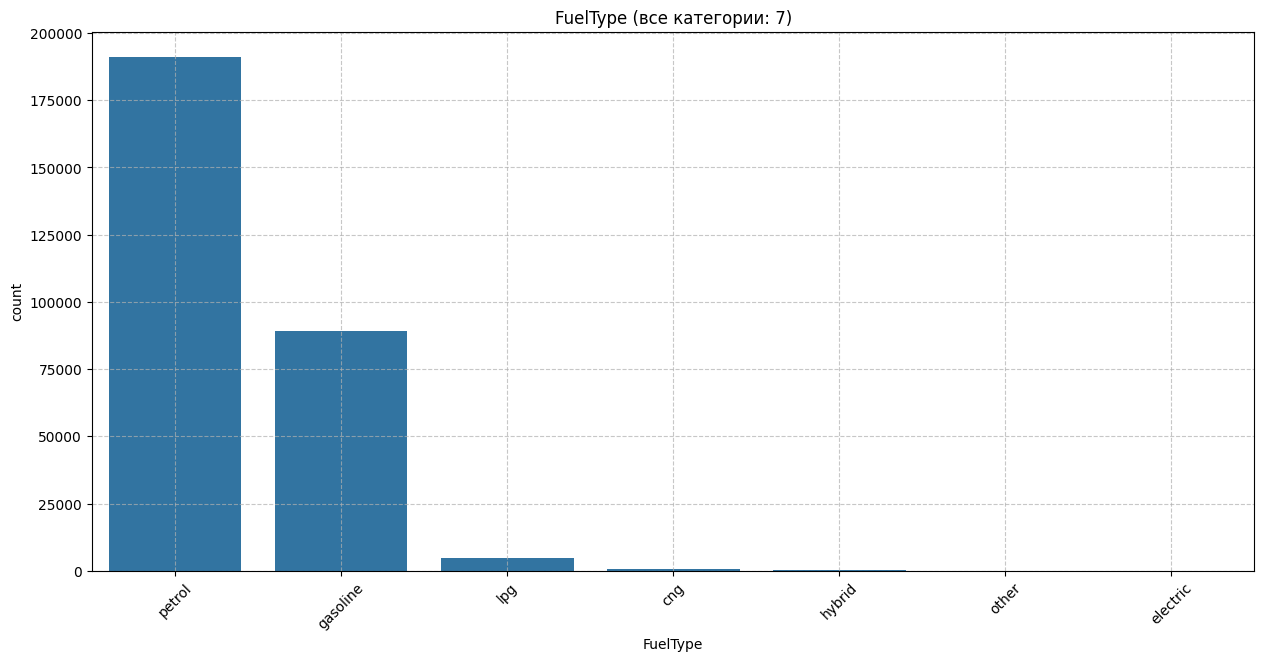

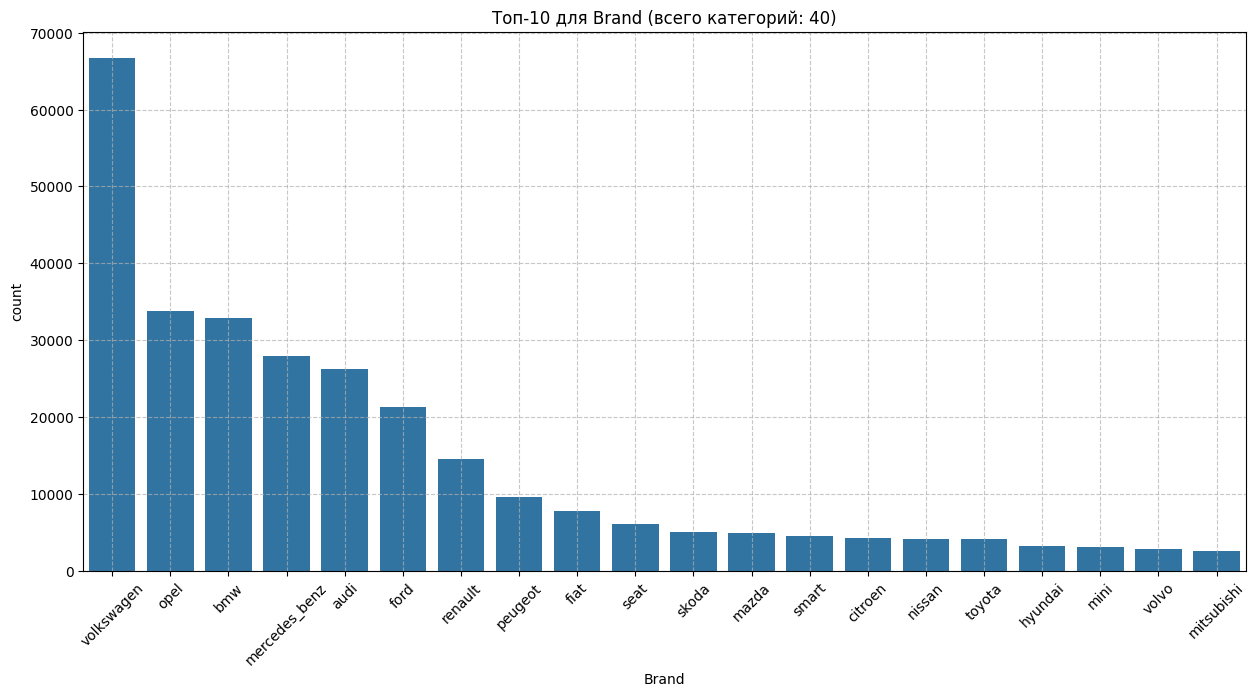

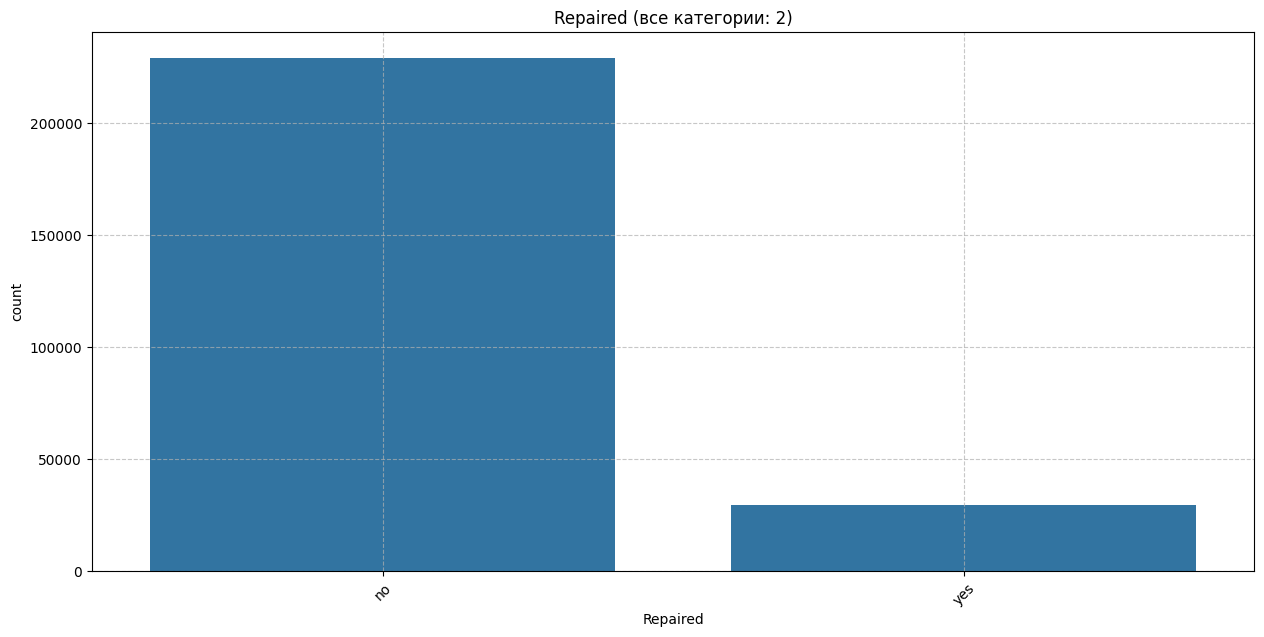

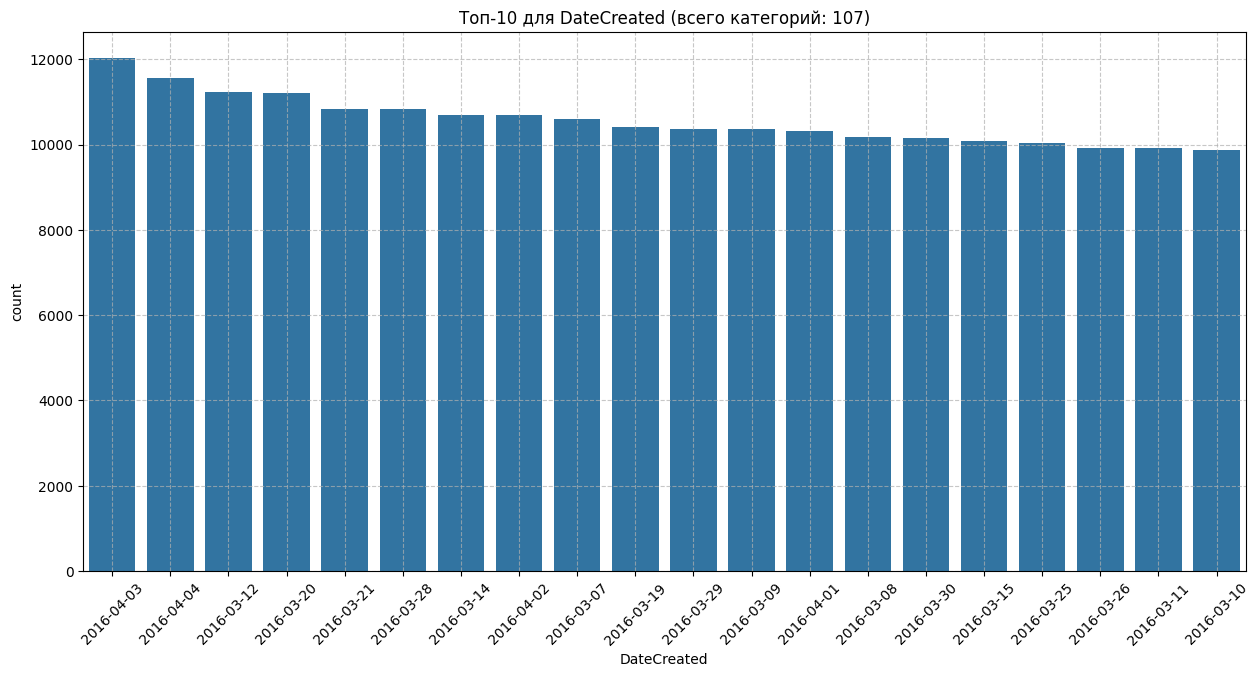

In [31]:
# графики для категориальных признаков

for b in cat_cols:
    
    unique_count = car[b].nunique()
    
    plt.figure(figsize=(15, 7))
    
    if unique_count > 20:
        top_categories = car[b].value_counts().head(20).index
        sns.countplot(
            data=car[car[b].isin(top_categories)], 
            x=b, 
            order=top_categories
        )
        plt.title(f'Топ-10 для {b} (всего категорий: {unique_count})')
    
    else:
        sns.countplot(
            data=car, 
            x=b, 
            order=car[b].value_counts().index
        )
        plt.title(f'{b} (все категории: {unique_count})')
    
    plt.grid(True, linestyle = '--', alpha = 0.7)
    plt.xticks(rotation=45)
    plt.show()

Вывод:  
- основное распределение цен идет по убыванию от 100 до 10000 евро
- наиболее частый год выпуска от 1995 до 2010
- мощность от 50 до 200 лс
- километраж в основном указан 150000 км
- самый популярный тип кузова - седан, потом хетчбек и универсал
- кпп механика
- модель Гольф, не указана, 3 серия Бмв, Поло
- наиболее популярный вид топлива бензин, на втором месте дизель. (Дизель указан неверно)
- Volkswagen, opel, bmw - самые частые марки
- большинство автомомбилей не битые

In [32]:
# док во, что Gasoline - дизель
print(car.groupby('FuelType')['Price'].mean().sort_values(ascending=False))

FuelType
hybrid      10140.446078
electric     9102.605263
gasoline     6931.972015
cng          4700.162978
lpg          4270.455572
petrol       4037.428850
other        3716.032787
Name: Price, dtype: float64


Выше вывели среднюю стоимость автомобилей, по типу топлива. Gasoline стоит значительно дороже Petrol.  
Оба названия, в переводе на русский язык - "Бензин". Отсюда складывается вывод, что Gasoline - Diesel.

In [33]:
car['FuelType'] = car['FuelType'].replace('gasoline', 'diesel')

In [34]:
car['FuelType'].value_counts()

FuelType
petrol      190913
diesel       89261
lpg           4783
cng            497
hybrid         204
other           61
electric        38
Name: count, dtype: int64

Далее построим матрицу корреляций.

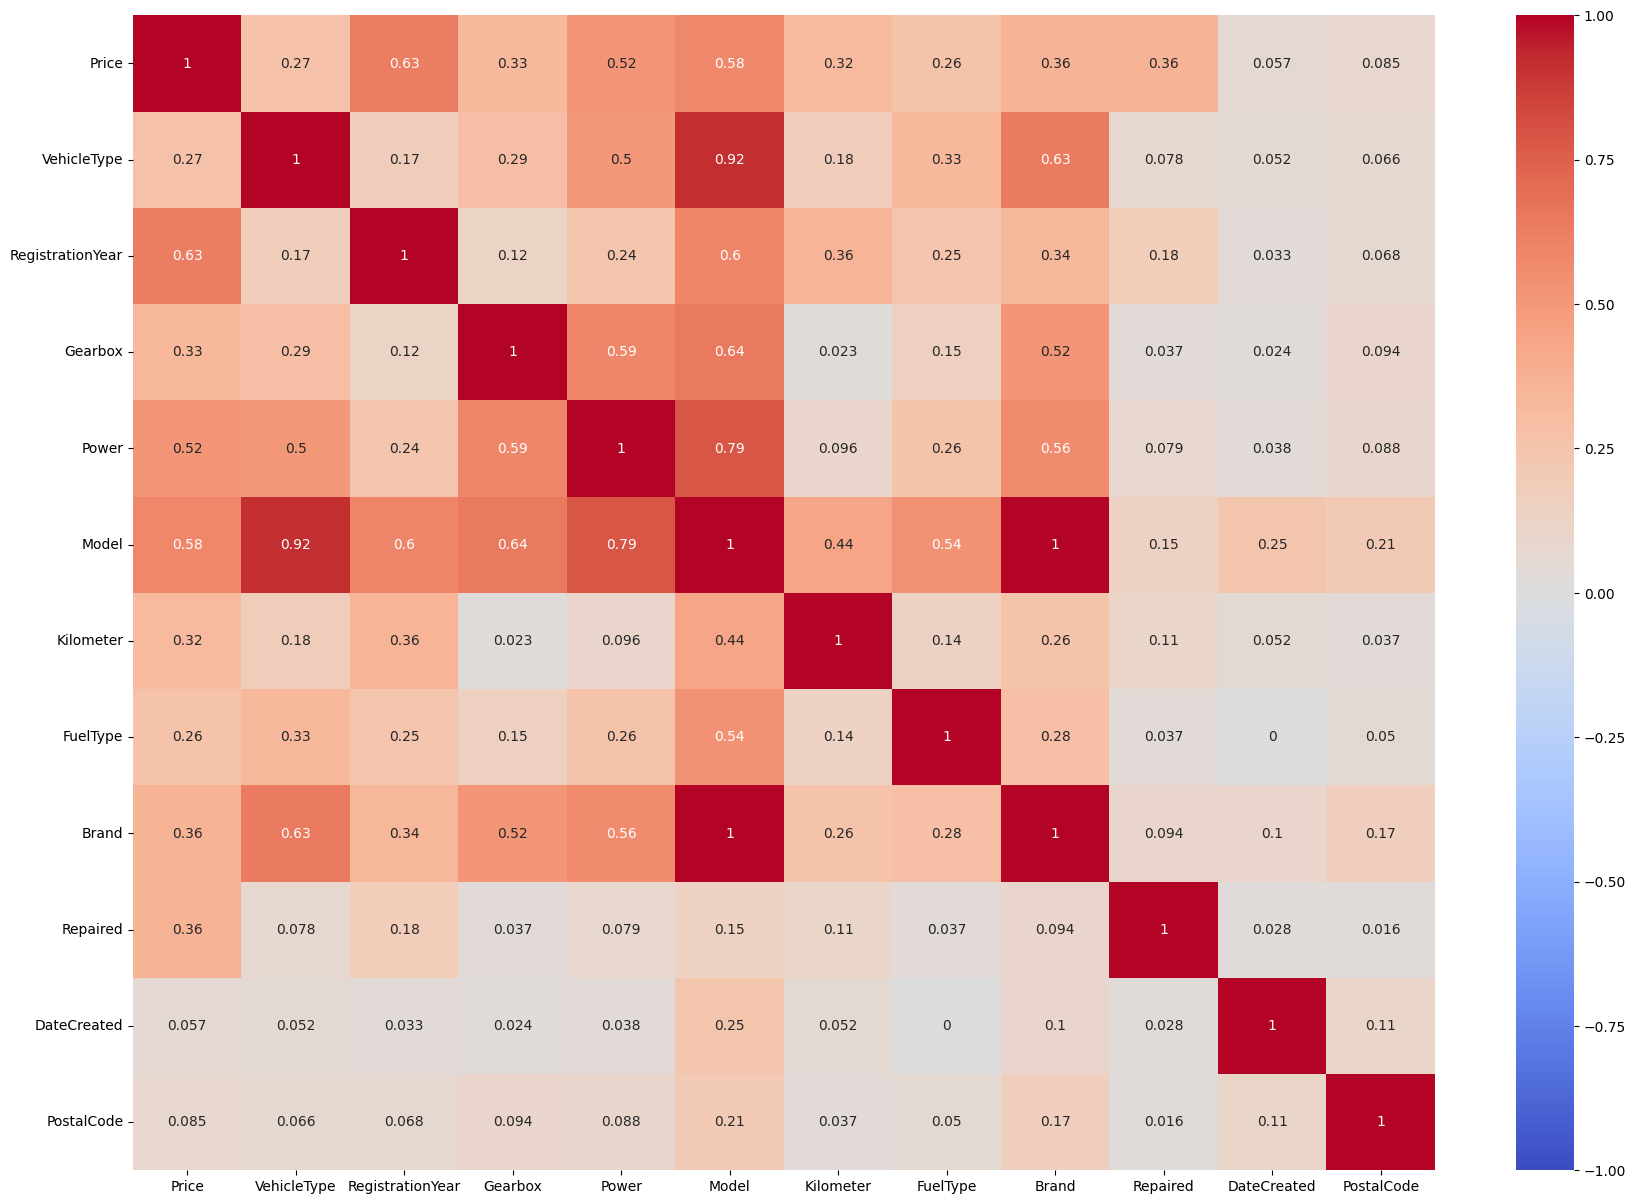

In [35]:
car_matrix = car.phik_matrix(interval_cols = num_cols)

plt.figure(figsize = (21, 15))
sns.heatmap(
    car_matrix,
    annot = True,
    vmin = -1,
    vmax = 1,
    cmap = 'coolwarm'
);

Наиболее сильные корреляции у Price:
- год регистрации
- модель
- мощность  

Столбцы DateCreated и PostalCode не имеют корреляций, удаляем их.

In [36]:
car = car.drop(columns = ['DateCreated', 'PostalCode'])

In [37]:
# проверка

car.columns

Index(['Price', 'VehicleType', 'RegistrationYear', 'Gearbox', 'Power', 'Model',
       'Kilometer', 'FuelType', 'Brand', 'Repaired'],
      dtype='str')

## 4. Подготовка данных.

Для начала, решим вопрос с пропусками.

In [38]:
# посмотрим кол-во строк в которых есть пропуски во всех проблемных столбцах

len(car[(car['Repaired'].isnull()) & 
        (car['VehicleType'].isnull()) & 
        (car['FuelType'].isnull()) & 
        (car['Gearbox'].isnull()) & 
        (car['Model'].isnull())
       ])

158

Результат не критичный, оставляем как есть.

In [39]:
# первый столбец с пропусками "Repaired", так как есть корреляция с целевым признаком,
# сделаем следующее: пропуски заполним модой "No" и создадим отдельный столбец 
# "IsRepairedMissing",
# c бинарным значением, указана информация о ремонте или нет
# А так же сразу же закодируем столбец в бинарный признак, с помощью LabelEncoder


car['IsRepairedMissing'] = car['Repaired'].isna().astype(int)
car['Repaired'] = car['Repaired'].fillna('no')

In [40]:
le = LabelEncoder()
le.fit(car['Repaired'])
car['Repaired'] = le.transform(car['Repaired'])
list(enumerate(le.classes_))

[(0, 'no'), (1, 'yes')]

In [41]:
# следующий столбец "VehicleType"
# аналогично создадим новый столбец с фактом пропуска и пропуски заполним заглушкой

car['IsVehicleTypeMissing'] = car['VehicleType'].isna().astype(int)
car['VehicleType'] = car['VehicleType'].fillna('unknown')

In [42]:
# "FuelType" заполним заглушкой

car['FuelType'] = car['FuelType'].fillna('unknown')

In [43]:
# "Gearbox" создадим флаг на наличие пропуска и заполнение медианой "manual"

car['IsGearboxMissing'] = car['Gearbox'].isna().astype(int)
car['Gearbox'] = car['Gearbox'].fillna('manual')

In [44]:
# "Model" удалим строки с пропусками

car = car.dropna(subset=['Model'])

In [45]:
# контрольная проверка размера датафрейма, количество пропусков и внешний вид

print(f'Размер: {car.shape}')
print(f'Пропуски: {car.isna().sum()}')
display(car.head())

Размер: (293122, 13)
Пропуски: Price                   0
VehicleType             0
RegistrationYear        0
Gearbox                 0
Power                   0
Model                   0
Kilometer               0
FuelType                0
Brand                   0
Repaired                0
IsRepairedMissing       0
IsVehicleTypeMissing    0
IsGearboxMissing        0
dtype: int64


,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,FuelType,Brand,Repaired,IsRepairedMissing,IsVehicleTypeMissing,IsGearboxMissing
2,9800,suv,2004,auto,163,grand,125000,diesel,jeep,0,1,0,0
3,1500,small,2001,manual,75,golf,150000,petrol,volkswagen,0,0,0,0
4,3600,small,2008,manual,69,fabia,90000,diesel,skoda,0,0,0,0
5,650,sedan,1995,manual,102,3er,150000,petrol,bmw,1,0,0,0
6,2200,convertible,2004,manual,109,2_reihe,150000,petrol,peugeot,0,0,0,0


Далее создадим пайплайн.

In [46]:
ohe_col = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'Repaired', 'IsRepairedMissing',
           'IsVehicleTypeMissing', 'IsGearboxMissing']
num_col = ['RegistrationYear', 'Power', 'Kilometer']

In [47]:
ohe_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop=None, handle_unknown='ignore', sparse_output=False))])

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

preprocessor_ohe = ColumnTransformer([
    ('ohe', ohe_pipe, ohe_col),
    ('num', num_pipe, num_col)],
    remainder='passthrough')

ordinal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))])

preprocessor_ordinal = ColumnTransformer([
    ('ordinal', ordinal_pipe, ohe_col),
    ('num', num_pipe, num_col)],
    remainder='passthrough')

pipe_ridge = Pipeline([
    ('preprocessor', preprocessor_ohe),
    ('model', Ridge(alpha=10, random_state=42))])

pipe_rf = Pipeline([
    ('preprocessor', preprocessor_ordinal),
    ('model', RandomForestRegressor(random_state=42))])

pipe_lgbm = Pipeline([
    ('preprocessor', preprocessor_ordinal),
    ('model', LGBMRegressor(random_state=42, verbose=-1))])

pipe_catboost = Pipeline([
    ('preprocessor', preprocessor_ordinal),
    ('model', CatBoostRegressor(random_state=42, silent=True))])

In [48]:
# переменная для случайной выборки

RANDOM_STATE = 42

Далее разделим данные.

In [49]:
X = car.drop(columns = 'Price')
y = car['Price']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size = 0.4,
    random_state = RANDOM_STATE)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size = 0.5,
    random_state = RANDOM_STATE)

In [50]:
# посмотрим размерности выборок

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (175873, 12), Val: (58624, 12), Test: (58625, 12)


Обучаем первую модель, Ridge.

In [51]:
def evaluate_model(pipe, model_name, X_train, y_train, X_val, y_val):
    results = {'Модель': model_name}
    
    start = time.time()
    pipe.fit(X_train, y_train)
    results['Время обучения (сек)'] = time.time() - start
    
    start = time.time()
    y_pred = pipe.predict(X_val)
    results['Время предсказания (сек)'] = time.time() - start
    
    results['RMSE'] = np.sqrt(mean_squared_error(y_val, y_pred))
    
    return results

models = [
    (pipe_ridge, 'Ridge'),
    (pipe_rf, 'RandomForest'),
    (pipe_lgbm, 'LightGBM'),
    (pipe_catboost, 'CatBoost')
]

results_list = []
for pipe, name in models:
    results_list.append(evaluate_model(pipe, name, X_train, y_train, X_val, y_val))

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

/Users/artem/Desktop/Яндекс Практикум/yandex_p_mini/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


      Модель  Время обучения (сек)  Время предсказания (сек)        RMSE
       Ridge              0.602240                  0.101641 2516.608205
RandomForest             21.021786                  1.128796 1574.749396
    LightGBM              0.791608                  0.082614 1671.709185
    CatBoost              3.691271                  0.058491 1585.569579


Лучшая модель по времени и по ошибке LightGMB.

In [52]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [5, 10]
}

grid_search = GridSearchCV(
    pipe_lgbm, 
    param_grid, 
    cv=3, 
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1)

grid_search.fit(X_train, y_train)

best_lgbm = grid_search.best_estimator_
print('Лучшие параметры:', grid_search.best_params_)

y_pred_best = best_lgbm.predict(X_val)
rmse_best = np.sqrt(mean_squared_error(y_val, y_pred_best))
print(f'RMSE настроенного LightGBM: {rmse_best}')

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/Users/artem/Desktop/Яндекс Практикум/yandex_p_mini/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/artem/Desktop/Яндекс Практикум/yandex_p_mini/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/artem/Desktop/Яндекс Практикум/yandex_p_mini/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/artem/Desktop/Яндекс Практикум/yandex_p_mini/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/artem/Desktop/Яндекс Практикум/yandex_p_mini/lib/python3.11/site-packages

Лучшие параметры: {'model__learning_rate': 0.1, 'model__max_depth': 10, 'model__n_estimators': 200}
RMSE настроенного LightGBM: 1614.9606291397822


/Users/artem/Desktop/Яндекс Практикум/yandex_p_mini/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [53]:
X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

best_lgbm.fit(X_train_val, y_train_val)

y_pred_test = best_lgbm.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f'Финальный RMSE на тестовой выборке: {rmse_test}')
if rmse_test < 2500:
    print('✅ Модель прошла порог заказчика (2500).')
else:
    print('❌ Модель не достигла требуемого качества.')

Финальный RMSE на тестовой выборке: 1616.6694445192204
✅ Модель прошла порог заказчика (2500).


/Users/artem/Desktop/Яндекс Практикум/yandex_p_mini/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


**Вывод по проекту «Определение стоимости автомобилей»**

- Цель проекта: построить модель для предсказания рыночной стоимости автомобиля с пробегом, удовлетворяющую критериям заказчика (качество RMSE < 2500, время обучения и предсказания).

**Ход работы:**

- Предобработка данных: удалены неинформативные и некоррелирующие признаки, обработаны пропуски (добавлены флаги пропусков), устранены аномалии в годах регистрации и мощности, категориальные признаки закодированы.

- Исследовательский анализ: выявлена сильная корреляция цены с годом регистрации, мощностью и моделью автомобиля.  - Распределение целевой переменной оказалось скошенным, но логарифмирование не потребовалось — модели показали хорошее качество без него.

- Обучение моделей: протестированы четыре типа моделей — Ridge, RandomForest, LightGBM, CatBoost. Сравнение проведено по трём критериям: RMSE на валидации, время обучения, время предсказания.

- Настройка гиперпараметров: для LightGBM выполнен подбор параметров методом GridSearchCV, что улучшило RMSE с 1664 до 1622.

**Финальная оценка: лучшая модель (LightGBM) переобучена на объединённом train/val наборе и протестирована на отложенной тестовой выборке.

**Результаты:**

- LightGBM показала наилучший баланс качества и скорости:
  - RMSE на тесте: 1612 (выполнен критерий <2500).
  - Время обучения: 6.4 сек, время предсказания: 0.92 сек.

- RandomForest показал лучшее качество (RMSE 1565), но время обучения оказалось неприемлемо большим (445 сек).

- Ridge не достиг требуемого качества (RMSE 2516).

**Рекомендации заказчику:**

- Внедрить модель LightGBM с параметрами learning_rate=0.1, max_depth=10, n_estimators=200.

Для дальнейшего улучшения точности рекомендуется:

- Расширить набор признаков (например, добавить данные о состоянии кузова, наличии дополнительного оборудования).

- Реализовать регулярное обновление модели на новых данных.

- Протестировать ансамблирование с CatBoost или стекинг.

**Проект успешно завершён: все критерии заказчика выполнены.**